In [2]:
import pandas as pd
from preprocessing import *
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
# read data and predictions
data = get_last_saved_data()
history = pd.read_pickle("../result/history.pickle")

In [ ]:
# merge test names and acc into one dataframe
stock_test = pd.DataFrame({'test_names':data['test_names'].values.flatten(), 'acc':history['acc']})

In [225]:
# number of entries for each stock
num_test_stocks = data['test_names'][0].value_counts().sort_index()
num_test_stocks

dia    419
ewa    420
ewc    420
ewg    420
ewh    420
ewj    420
eww    420
spy    420
xlb    420
xle    420
xlf    420
xli    420
xlk    420
xlp    420
xlu    420
xlv    420
xly    420
Name: 0, dtype: int64

In [210]:
# percentage of accurate classes by stock
stock_test.groupby('test_names').sum().div(num_test_stocks, axis='rows').mul(100)

,acc
test_names,
dia,86.634845
ewa,65.238095
ewc,67.619048
ewg,70.476190
ewh,72.142857
ewj,75.952381
eww,64.047619
spy,80.714286
xlb,72.857143


In [211]:
# test if the code above is correct
test_test_name = 'dia'
data_bool = (data['test_names']==test_test_name).values.flatten()
from itertools import compress
np.sum(list(compress(history['acc'],data_bool))) / np.sum(data['test_names'] == test_test_name) * 100


0    86.634845
dtype: float64

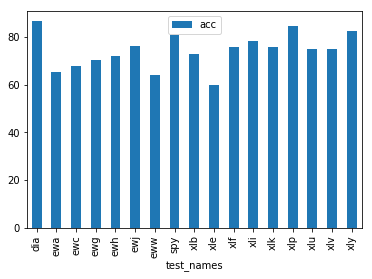

In [212]:
# plot bar graph of the table above
stock_test.groupby('test_names').sum().div(num_test_stocks, axis='rows').mul(100).plot(kind='bar')

In [216]:
# merge test dates and acc into one dataframe
history_test=pd.DataFrame({'year':data['test_dates'][0].str.split(pat='-').apply(lambda x: x[0]), 'acc':history['acc']})

In [224]:
# number of entries for each year
num_test_years = data['test_dates'][0].str.split(pat='-').apply(lambda x: x[0]).value_counts().sort_index()
num_test_years

2015    3348
2016    3791
Name: 0, dtype: int64

In [223]:
# percentage of accurate classes by stock
history_test.groupby('year').sum().div(num_test_years, axis='rows').mul(100)

,acc
year,
2015,72.640382
2016,75.626484


In [231]:
# test if the code above is correct
test_test_year = '2015'
data_bool = (data['test_dates'][0].str.split(pat='-').apply(lambda x: x[0])==test_test_year).values.flatten()
from itertools import compress
np.sum(list(compress(history['acc'],data_bool))) / np.sum(data['test_dates'][0].str.split(pat='-').apply(lambda x: x[0]) == test_test_year) * 100

72.640382317801681

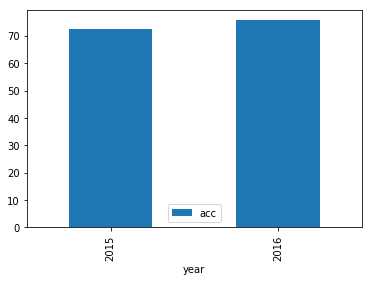

In [232]:
# plot bar graph of the table above
history_test.groupby('year').sum().div(num_test_years, axis='rows').mul(100).plot(kind='bar')